In [20]:
import pandas as pd
import re
import matplotlib.pyplot as plt

In [15]:
df = pd.read_csv('DS6021-Fall26-Anonymized.csv')
df.head()

,Timestamp,What was your undergraduate major?,What type of phone do you have?,How many years ago did you receive your undergraduate degree?,How many hours do you sleep in a typical night?,Rate your proficiency with git/github,Rate your proficiency with Python,Have you ever used SQL?,What is your favorite sport to watch on tv?,What is your ideal outdoor temperature (in Fahrenheit)?,How many US states have you visited?,What is your favorite season?
0,8/25/2026 8:20:43,Psychology,iPhone,4-6 years,8,3,2,Yes,F1 motorsport,70,8,Fall
1,8/25/2026 9:35:51,Statistics,iPhone,1-3 years,8,3,4,Yes,NaN,70,16,Fall
2,8/25/2026 13:43:23,Economics-Business and Applied Mathematics,iPhone,< 1 year,8,3,3,No,Baseball,70,27,Fall
3,8/25/2026 15:11:38,Data Science (concentration in Computer Science),iPhone,< 1 year,8,3,4,Yes,Football (go Bears!),73,9,Fall
4,8/25/2026 15:26:11,Math and Physics,iPhone,1-3 years,8,2,4,Yes,Figure Skating,73,26,Fall


In [19]:
print(list(df['Timestamp'].unique()))
print(list(df['What was your undergraduate major?'].unique()))
print(list(df['What type of phone do you have?'].unique()))
print(list(df['How many years ago did you receive your undergraduate degree?'].unique()))
print(list(df['How many hours do you sleep in a typical night?'].unique()))
print(list(df['Rate your proficiency with git/github'].unique()))
print(list(df['Rate your proficiency with Python'].unique()))
print(list(df['Have you ever used SQL?'].unique()))
print(list(df['What is your favorite sport to watch on tv?'].unique()))
print(list(df['What is your ideal outdoor temperature (in Fahrenheit)?'].unique()))
print(list(df['How many US states have you visited?'].unique()))
print(list(df['What is your favorite season?'].unique()))
print(df.dtypes)

[Timestamp('2026-08-25 08:20:43'), Timestamp('2026-08-25 09:35:51'), Timestamp('2026-08-25 13:43:23'), Timestamp('2026-08-25 15:11:38'), Timestamp('2026-08-25 15:26:11'), Timestamp('2026-08-25 20:43:55'), Timestamp('2026-08-26 10:10:40'), Timestamp('2026-08-26 10:11:02'), Timestamp('2026-08-26 10:11:07'), Timestamp('2026-08-26 10:11:18'), Timestamp('2026-08-26 10:11:20'), Timestamp('2026-08-26 10:11:25'), Timestamp('2026-08-26 10:11:27'), Timestamp('2026-08-26 10:11:35'), Timestamp('2026-08-26 10:11:38'), Timestamp('2026-08-26 10:11:47'), Timestamp('2026-08-26 10:11:50'), Timestamp('2026-08-26 10:11:51'), Timestamp('2026-08-26 10:11:54'), Timestamp('2026-08-26 10:12:09'), Timestamp('2026-08-26 10:12:14'), Timestamp('2026-08-26 10:12:27'), Timestamp('2026-08-26 10:12:28'), Timestamp('2026-08-26 10:12:43'), Timestamp('2026-08-26 10:13:01'), Timestamp('2026-08-26 10:13:19'), Timestamp('2026-08-26 10:13:25'), Timestamp('2026-08-26 10:13:30'), Timestamp('2026-08-26 10:13:33'), Timestamp('20

In [18]:
df = pd.read_csv('DS6021-Fall26-Anonymized.csv')

#Values are a date and a time so a datetime is a better match
df['Timestamp'] = df['Timestamp'].astype('datetime64[ns]')

#Pulling the first number from the answer and converting into a float for computation
#Does create some data loss since it only takes the first number, but is the simplist solution
df['How many hours do you sleep in a typical night?'] = df['How many hours do you sleep in a typical night?'].str.extract(r'(\d+)', expand=False).astype('float64')

#Values are true/false so converting to boolean is a better match
df['Have you ever used SQL?'] = df['Have you ever used SQL?'] == 'Yes'

#Convert to a float for easier computation of stats same as hours of sleep same limitations
df['What is your ideal outdoor temperature (in Fahrenheit)?'] = df['What is your ideal outdoor temperature (in Fahrenheit)?'].str.extract(r'(\d+)', expand=False).astype('float64')

#Convert to a float for easier computation of stats same as hours of sleep same limitations
df['How many US states have you visited?'] = df['How many US states have you visited?'].str.extract(r'(\d+)', expand=False).astype('float64')

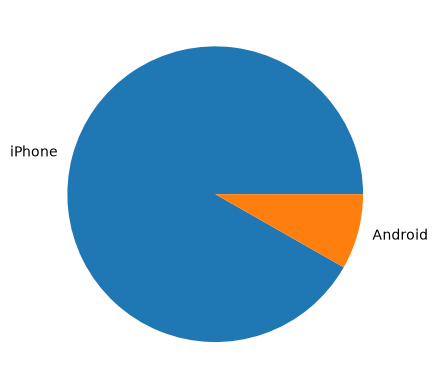

In [29]:
df['What type of phone do you have?'].value_counts().plot.pie()
plt.show()


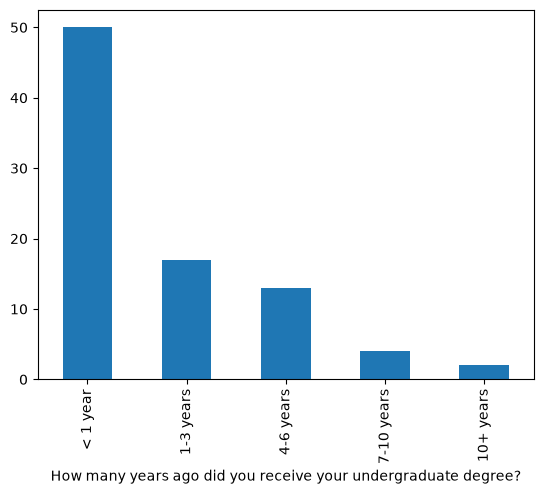

In [27]:
df['How many years ago did you receive your undergraduate degree?'].value_counts().plot.bar()
plt.show()

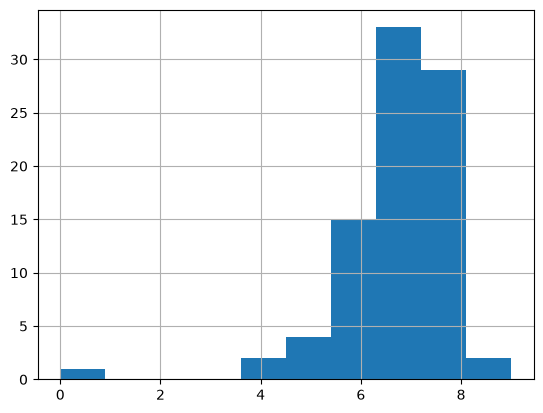

In [26]:
df['How many hours do you sleep in a typical night?'].hist()
plt.show()

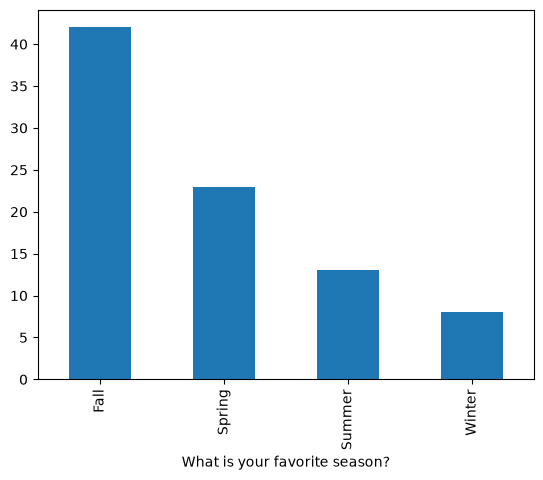

In [28]:
df['What is your favorite season?'].value_counts().plot.bar()
plt.show()

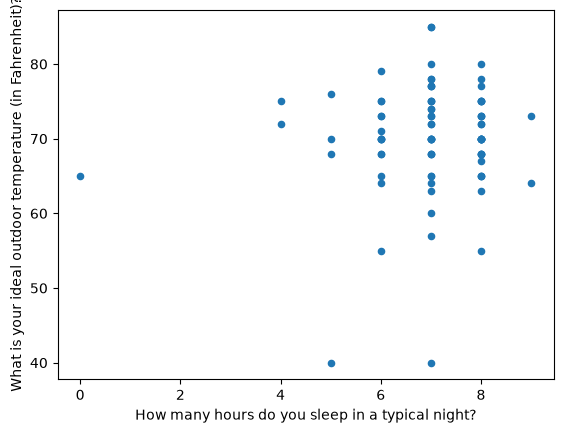

In [36]:
df.plot.scatter(x='How many hours do you sleep in a typical night?', y='What is your ideal outdoor temperature (in Fahrenheit)?')
plt.show()

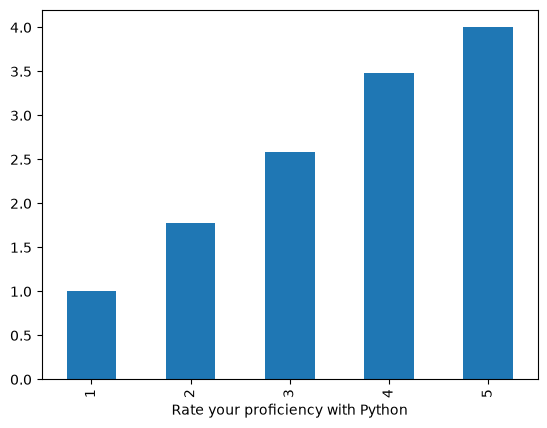

In [35]:
df.groupby('Rate your proficiency with Python')['Rate your proficiency with git/github'].mean().plot(kind='bar')
plt.show()

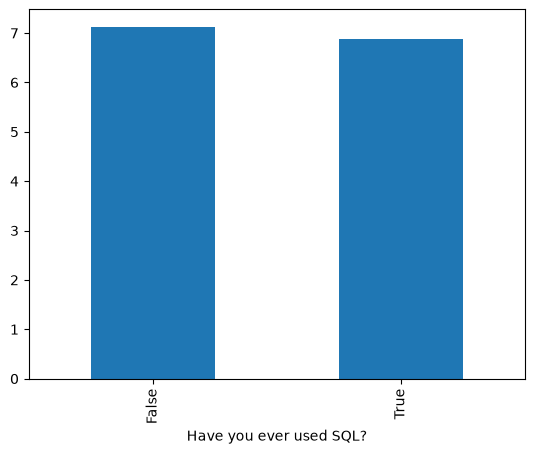

In [38]:
df.groupby('Have you ever used SQL?')['How many hours do you sleep in a typical night?'].mean().plot(kind='bar')
plt.show()

Short Summary
	For my first chart, I used a pie chart to compare the proportion of iPhone users to Android users, with iPhone clearly dominating. Then, for the second chart, I made a bar chart for the count of students by how long it had been since their undergraduate degree, with the majority being less than a year. The third chart I made was a histogram for the number of hours of sleep; most saw 7 to 8, but there was a 0 outlier due to the limitation of how I cleaned the data. The last single variable chart I made was a bar chart of the counts of entries by season, with fall being the winner.
	On to the multiple variable charts. The first I did was a scatter plot for how many hours someone sleeps against ideal temperature. I was curious if there was any correlation there, but no pattern in the chart. The second I did was a bar chart of the average proficiency in git against the different Python proficiency levels, and not surprisingly, they were positively correlated. The last chart I did was a bar chart to see the difference in average hours of sleep by whether someone had proficiency in SQL, with no difference there.

Reflections

Is there anything about the dataset that surprised you?
	The first two charts were surprising to me. I was expecting Android to do at least a little better, but that was probably my bias because I have one. The second chart, looking at the number of years out of undergrad, I was expecting it to skew short but thought there would be more of a balance between under 1 year and 1-3 years.

For some of the survey response questions, there are multiple ways that one could clean the data. For two different examples where you had a choice to make, please discuss the alternatives that you considered and why you made the choice that you ultimately did.
	I had the largest issue with the text entries for numerical data like the number of hours of sleep, ideal outdoor temperature, and number of stated visits. For these three variables, there was a decent variety in the way people entered them. I ended up going with using regular expressions to pull the first number from the string mostly for simplicity. This has plenty of limitations, though, and I considered more complex options like creating a list of all the numbers in the string or getting the average of the numbers in the string. I also used floats since that helped for strings without numbers.

In the first part of this assignment, I asked you to use Python as opposed to cleaning the data in Excel or Google Sheets. In a business context, what is a potential negative outcome that could occur if you did this in Excel or Google Sheets?
	The largest gap with using a tool like Excel or Google Sheets compared to coding is the scalability. While a one-off analysis of a data set like this would be fine for them, anything that would grow over time or be used more regularly, like in a production business context, would be much more robust written in code.
